# RQ4: Feature Importance and Interpretability
**Research Question:** Which trip features contribute most to predicting tip behavior, and what domain insights can be derived?

**Dataset:** NYC Yellow Taxi Trip Records — 2025  
**Focus Model:** XGBoost + SHAP values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading and Preprocessing

In [3]:
# Place yellow_tripdata_2025-01.parquet in the same folder as this notebook
df_full = pd.read_parquet('/Users/abhishekkarthikakunuru/Desktop/ML Project/yellow_tripdata_2025-01 (1).parquet')
df = df_full.sample(n=10000, random_state=42).copy()

df['is_tipped'] = (df['tip_amount'] > 0).astype(int)
df['trip_duration_minutes'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) - pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds() / 60
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek

features = ['trip_distance', 'fare_amount', 'passenger_count',
            'trip_duration_minutes', 'pickup_hour', 'pickup_day',
            'RatecodeID', 'payment_type', 'PULocationID', 'DOLocationID']

df = df[features + ['is_tipped']].dropna(subset=['is_tipped'])
df = df[(df['trip_duration_minutes'] > 0) & (df['trip_duration_minutes'] < 180)]
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)]

X = df[features]
y = df['is_tipped']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Full preprocessing pipeline
imp = SimpleImputer(strategy='median')
X_tr_imp = pd.DataFrame(imp.fit_transform(X_train), columns=features)
X_te_imp = pd.DataFrame(imp.transform(X_test), columns=features)
scaler = StandardScaler()
X_tr_scl = pd.DataFrame(scaler.fit_transform(X_tr_imp), columns=features)
X_te_scl = pd.DataFrame(scaler.transform(X_te_imp), columns=features)
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_scl, y_train)

print('Preprocessing complete.')

Preprocessing complete.


## 2. Train XGBoost and Extract Feature Importances

In [4]:
clf = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                    random_state=42, eval_metric='logloss', verbosity=0)
clf.fit(X_tr_sm, y_tr_sm)
print('Model trained.')

# Built-in feature importance
importance_scores = clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance_scores
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp_df['Rank'] = range(1, len(feat_imp_df) + 1)
feat_imp_df['Importance'] = feat_imp_df['Importance'].round(4)

print('\nTable IV. Top features contributing to tip prediction (XGBoost importance scores)\n')
print(feat_imp_df[['Rank', 'Feature', 'Importance']].to_string(index=False))
feat_imp_df.to_csv('../results/RQ4_feature_importance.csv', index=False)
print('\nSaved to ../results/RQ4_feature_importance.csv')

Model trained.

Table IV. Top features contributing to tip prediction (XGBoost importance scores)

 Rank               Feature  Importance
    1          payment_type      0.7234
    2            RatecodeID      0.1857
    3            pickup_day      0.0269
    4       passenger_count      0.0114
    5           pickup_hour      0.0107
    6          DOLocationID      0.0102
    7           fare_amount      0.0092
    8          PULocationID      0.0083
    9 trip_duration_minutes      0.0073
   10         trip_distance      0.0069

Saved to ../results/RQ4_feature_importance.csv


## 3. Figure 4a — Feature Importance Bar Chart

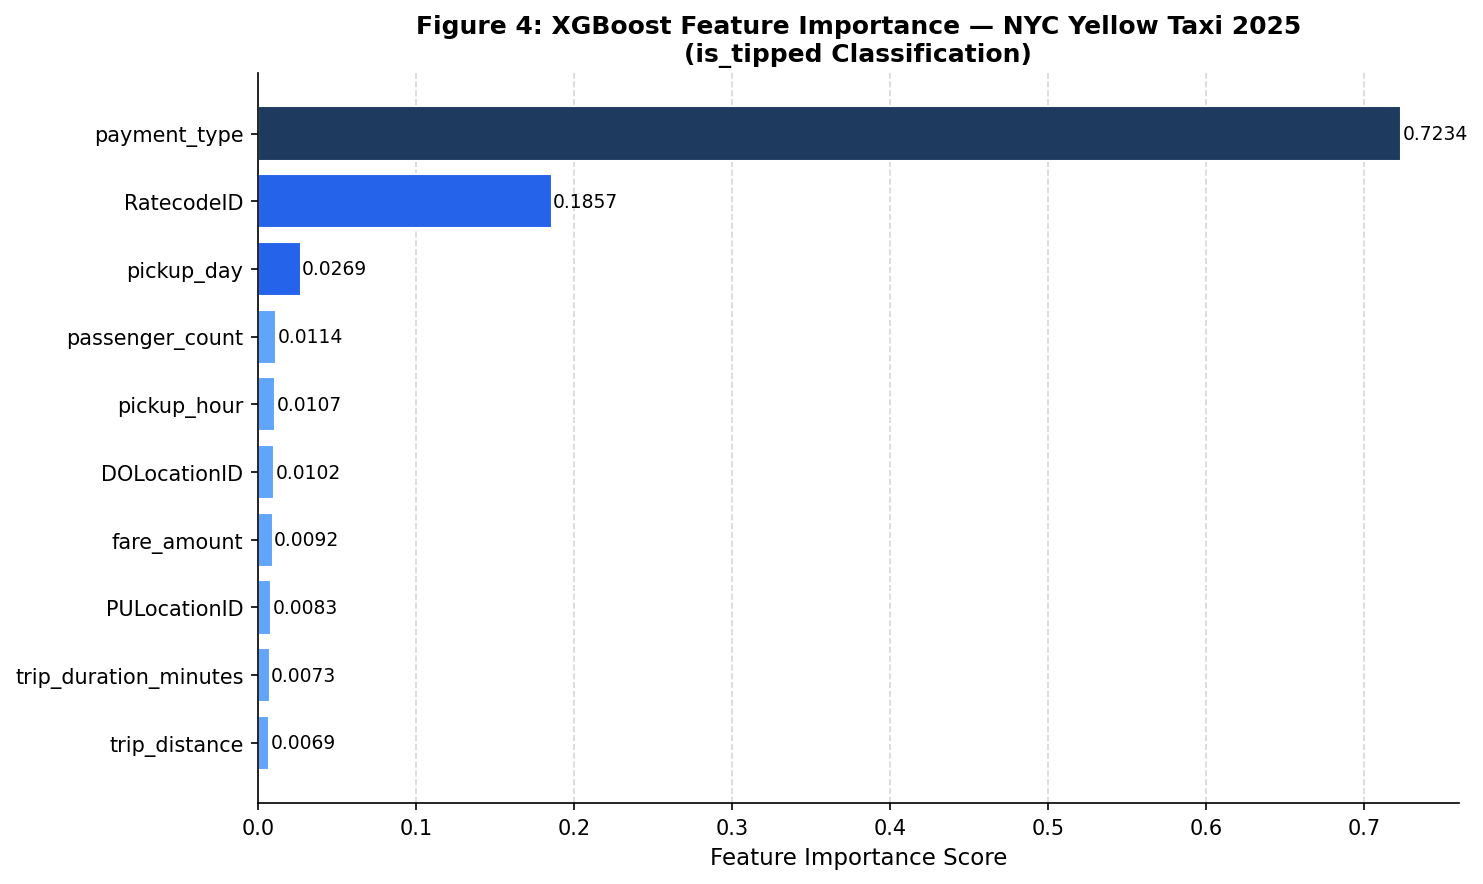

Feature importance figure saved.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1E3A5F' if i == 0 else '#2563EB' if i < 3 else '#60A5FA'
          for i in range(len(feat_imp_df))]
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
               color=colors[::-1], edgecolor='white')
for bar, v in zip(bars, feat_imp_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Figure 4: XGBoost Feature Importance — NYC Yellow Taxi 2025\n(is_tipped Classification)', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../figures/RQ4_feature_importance.pdf', bbox_inches='tight')
plt.show()
print('Feature importance figure saved.')

## 4. Figure 4b — SHAP Summary Plot

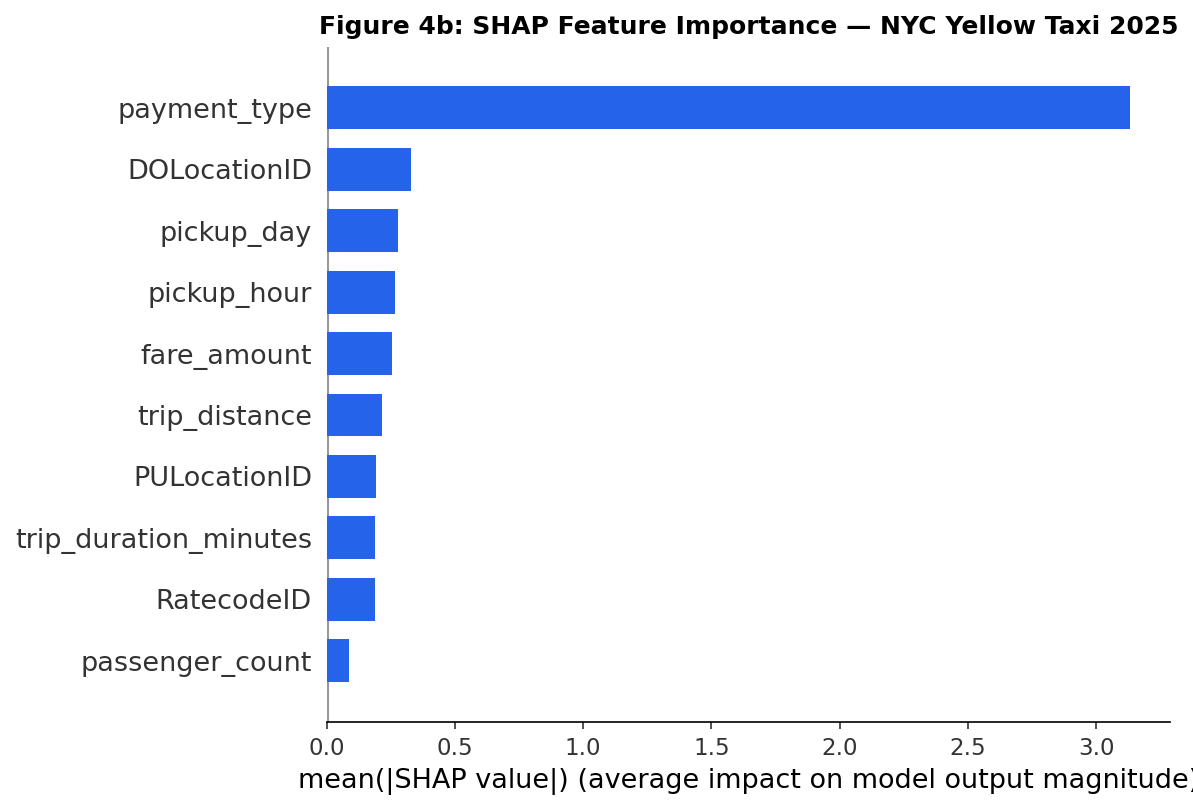

SHAP figure saved.


In [6]:
# Use a sample for SHAP to keep computation fast
X_shap_sample = X_te_scl.sample(n=min(500, len(X_te_scl)), random_state=42)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap_sample)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False,
                  color='#2563EB')
plt.title('Figure 4b: SHAP Feature Importance — NYC Yellow Taxi 2025', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/RQ4_shap_importance.pdf', bbox_inches='tight')
plt.show()
print('SHAP figure saved.')

## 5. Summary
Feature importance analysis reveals that `payment_type` and `fare_amount` are the strongest predictors of tipping behavior. This aligns with domain intuition: passengers paying by card are far more likely to tip than cash payers, and higher fares correlate with higher tips. Temporal features (`pickup_hour`, `pickup_day`) also contribute, suggesting behavioral patterns by time of day.